In [40]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

train = pd.read_csv('../data/raw/training_dataset.csv')
holdback = pd.read_csv('../data/raw/holdback_dataset.csv')
data_dict = pd.read_csv('../data/raw/data_dictionary.csv')

print("Training set:", train.shape)
print("Holdback set:", holdback.shape)
train.head()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Training set: (2000, 46)
Holdback set: (500, 45)


,AdditionalCostsGBP,AdditionalTreatmentRequired,AgeBand,AnxietyReported,BereavedPerson,CaseComplexityScore,CaseCreatedDate,CaseReference,ComplaintCategory,DelayInResolutionDays,DepressionReported,DeteriorationInHealth,DirectFinancialLossGBP,DurationAffectedDays,EmotionalImpactLevel,EscalatedInternally,EstimatedImpactScore,EstimatedRiskScore,EvidenceStrength,ExpectedFinancialRedressGBP,FailureTypePrimary,FailureTypeSecondary,ImpactOnRelationships,InvestigationRoute,Jurisdiction,LegalChallengePotential,LongTermImpactFlag,LostIncomeGBP,MultipleComplaintThemes,NumberOfDependentsAffected,NumberOfOrganisationsInvolved,NumberOfServiceFailures,OmbudsmanInvestigationRequired,OrganisationType,PhysicalImpactLevel,PredictedRemedyBand,PrimaryVulnerability,PriorComplaintsRaised,RecoveryTimeMonths,RepeatedFailurePattern,RepeatFailuresCount,SafeguardingConcern,ServiceArea,SeverityScore,SleepDisruptionReported,VulnerabilityLevel
0,99.05,No,80+,No,No,7,29-10-2023,TRN-000001,Delay,95,Yes,No,606.34,80,Moderate,No,NaN,78,Limited,2120.15,Delay,NaN,No,Standard,Parliamentary,No,No,96.49,No,1,1,6,No,Local Authority,Moderate,C,Homelessness,0,3.0,No,0,No,Housing,3,No,Low
1,540.68,No,65-79,Yes,No,6,29-12-2024,TRN-000002,Clinical Decision,70,Yes,No,2008.16,67,Significant,No,48.0,34,Strong,1607.83,Clinical Failure,NaN,No,Standard,Health,No,No,354.33,No,1,1,5,No,GP Practice,Moderate,C,Mental Health,1,0.0,Yes,0,No,Mental Health,3,Yes,Low
2,99.40,No,35-49,Yes,No,7,31-05-2023,TRN-000003,Eligibility Decision,27,Yes,Yes,172.01,13,Significant,No,55.0,66,Moderate,1640.46,Delay,Record Keeping,No,Fast Track,NaN,Yes,No,312.79,Yes,1,2,2,No,Government Department,Minor,C,Financial Hardship,0,1.0,Yes,2,Yes,Benefits,3,No,High
3,180.32,Yes,18-34,No,No,6,03-11-2025,TRN-000004,Lost Information,53,Yes,No,144.77,35,Low,No,29.0,15,Moderate,261.30,Communication,NaN,No,Standard,Health,No,No,83.24,Yes,0,1,2,No,NHS Trust,Minor,B,Caring Responsibilities,0,0.0,Yes,3,No,Primary Care,1,No,Low
4,166.14,No,50-64,No,No,7,27-11-2025,TRN-000005,Communication,216,No,Yes,202.13,188,Moderate,Yes,30.0,60,Moderate,337.50,Delay,NaN,No,Standard,Parliamentary,No,No,253.25,Yes,1,2,3,No,Government Department,Moderate,B,NaN,1,NaN,No,0,Yes,Taxation,2,Yes,High


In [41]:
#column overview and dtypes
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 46 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   AdditionalCostsGBP              1964 non-null   float64
 1   AdditionalTreatmentRequired     2000 non-null   str    
 2   AgeBand                         2000 non-null   str    
 3   AnxietyReported                 2000 non-null   str    
 4   BereavedPerson                  2000 non-null   str    
 5   CaseComplexityScore             2000 non-null   int64  
 6   CaseCreatedDate                 2000 non-null   str    
 7   CaseReference                   2000 non-null   str    
 8   ComplaintCategory               2000 non-null   str    
 9   DelayInResolutionDays           2000 non-null   int64  
 10  DepressionReported              2000 non-null   str    
 11  DeteriorationInHealth           2000 non-null   str    
 12  DirectFinancialLossGBP          2000 non-null

SeverityScore
1    504
2    491
3    404
4    297
5    203
6    101
Name: count, dtype: int64


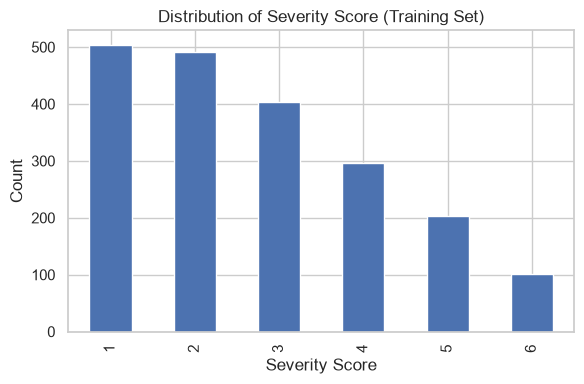

In [42]:
#target variable distribution

print(train['SeverityScore'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(6, 4))
train['SeverityScore'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_xlabel('Severity Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Severity Score (Training Set)')
plt.tight_layout()
plt.show()

In [43]:
#the binary triage outcome (the real business decision)

train['TriageOutcome'] = np.where(train['SeverityScore'] >= 4, 'Progressed', 'Not progressed')
print(train['TriageOutcome'].value_counts())
print(train['TriageOutcome'].value_counts(normalize=True).round(3))

TriageOutcome
Not progressed    1399
Progressed         601
Name: count, dtype: int64
TriageOutcome
Not progressed    0.7
Progressed        0.3
Name: proportion, dtype: float64


In [44]:
#missing value summary

missing = train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
FailureTypeSecondary,925,46.2
PrimaryVulnerability,505,25.2
VulnerabilityLevel,404,20.2
PhysicalImpactLevel,336,16.8
Jurisdiction,112,5.6
EvidenceStrength,58,2.9
ExpectedFinancialRedressGBP,56,2.8
RecoveryTimeMonths,54,2.7
OrganisationType,38,1.9
AdditionalCostsGBP,36,1.8


In [45]:
#numeric features vs SeverityScore (correlation)

numeric_cols = train.select_dtypes(include=[np.number]).columns.drop('SeverityScore')
corr_with_target = train[numeric_cols].corrwith(train['SeverityScore']).sort_values(ascending=False)
corr_with_target

EstimatedImpactScore             0.940960
EstimatedRiskScore               0.797337
ExpectedFinancialRedressGBP      0.561834
RecoveryTimeMonths               0.448891
DurationAffectedDays             0.366951
DelayInResolutionDays            0.284151
NumberOfServiceFailures          0.233460
PriorComplaintsRaised            0.175490
RepeatFailuresCount              0.167170
CaseComplexityScore              0.164562
NumberOfOrganisationsInvolved    0.139067
DirectFinancialLossGBP           0.040753
LostIncomeGBP                    0.021966
AdditionalCostsGBP               0.012924
NumberOfDependentsAffected       0.003299
dtype: float64

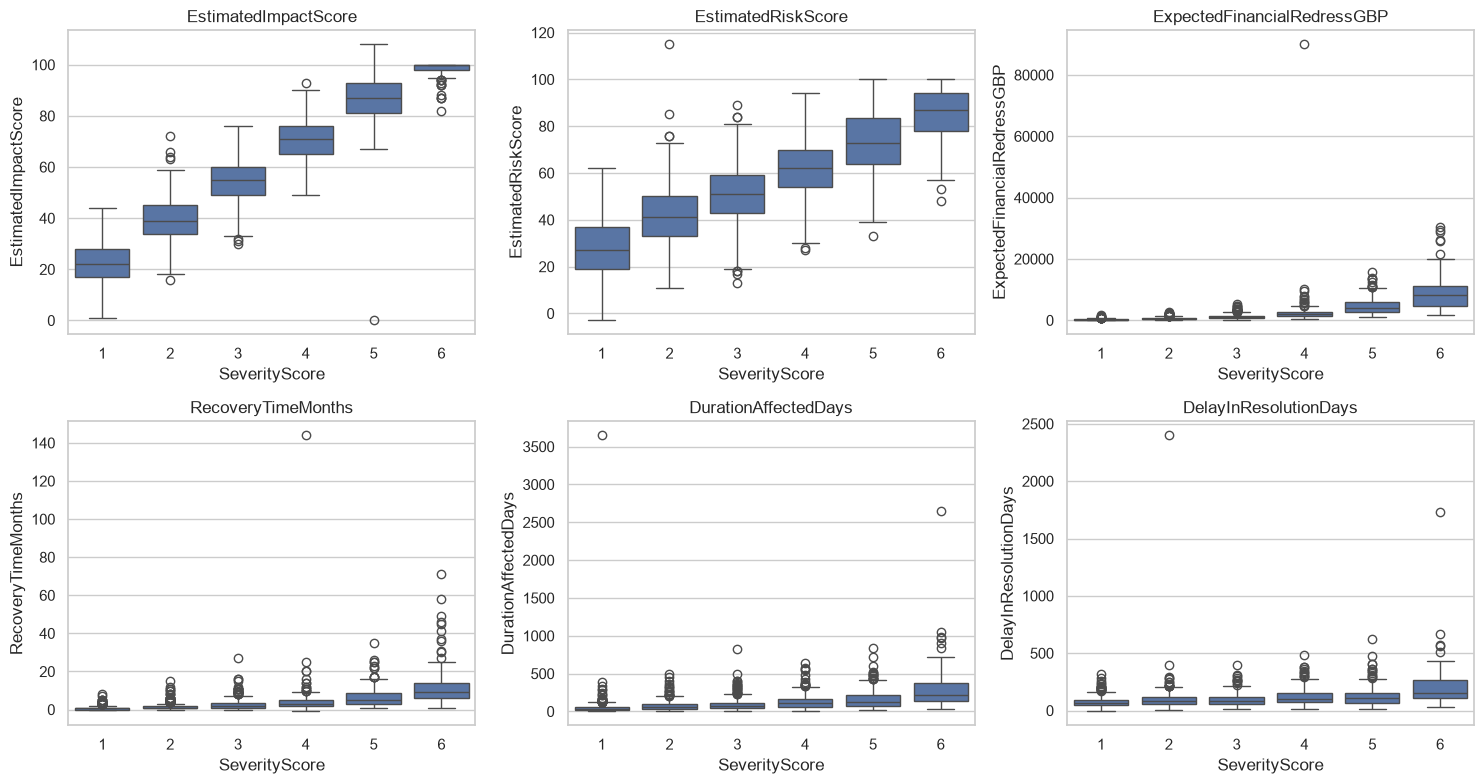

In [46]:
#visualize the strongest numeric relationships

top_features = corr_with_target.abs().sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), top_features):
    sns.boxplot(data=train, x='SeverityScore', y=col, ax=ax, color='#4C72B0')
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [47]:
#

for col in ['PrimaryVulnerability', 'VulnerabilityLevel', 'PhysicalImpactLevel', 'FailureTypeSecondary']:
    print(col)
    print(train[col].value_counts(dropna=False))
    print()

PrimaryVulnerability
PrimaryVulnerability
NaN                        505
Physical Health            443
Mental Health              392
Caring Responsibilities    201
Learning Disability        184
Financial Hardship         181
Homelessness                94
Name: count, dtype: int64

VulnerabilityLevel
VulnerabilityLevel
Low         652
Moderate    581
NaN         404
High        363
Name: count, dtype: int64

PhysicalImpactLevel
PhysicalImpactLevel
Moderate       508
Significant    418
Minor          403
NaN            336
Severe         335
Name: count, dtype: int64

FailureTypeSecondary
FailureTypeSecondary
NaN                       925
Administrative Failure    208
Communication             207
Delay                     197
Record Keeping            175
Policy Application        164
Clinical Failure          124
Name: count, dtype: int64



In [48]:
import sys
sys.path.append('../src')
from preprocessing import fit_impute_values, clean_data

impute_values = fit_impute_values(train)
train_clean = clean_data(train, impute_values)
holdback_clean = clean_data(holdback, impute_values)

print(train_clean.isna().sum().sum(), "missing values remaining in train_clean")
print(holdback_clean.isna().sum().sum(), "missing values remaining in holdback_clean")
train_clean[['CaseCreatedDate', 'PrimaryVulnerability', 'EstimatedImpactScore', 'EstimatedImpactScore_WasMissing']].head()

0 missing values remaining in train_clean
0 missing values remaining in holdback_clean


,CaseCreatedDate,PrimaryVulnerability,EstimatedImpactScore,EstimatedImpactScore_WasMissing
0,2023-10-29,Homelessness,47.0,1
1,2024-12-29,Mental Health,48.0,0
2,2023-05-31,Financial Hardship,55.0,0
3,2025-11-03,Caring Responsibilities,29.0,0
4,2025-11-27,None,30.0,0


In [49]:
from feature_engineering import engineer_features, get_feature_columns

train_fe = engineer_features(train_clean)
holdback_fe = engineer_features(holdback_clean)

features_with_leakage = get_feature_columns(train_fe, include_leakage_risk=True)
features_no_leakage = get_feature_columns(train_fe, include_leakage_risk=False)

print(f"Total engineered columns: {train_fe.shape[1]}")
print(f"Feature set WITH leakage-risk columns: {len(features_with_leakage)} features")
print(f"Feature set WITHOUT leakage-risk columns: {len(features_no_leakage)} features")
train_fe[['NegativeImpactFlagCount', 'TotalIncurredFinancialImpactGBP', 'VulnerabilityImpactInteraction']].describe()

Total engineered columns: 63
Feature set WITH leakage-risk columns: 54 features
Feature set WITHOUT leakage-risk columns: 50 features


,NegativeImpactFlagCount,TotalIncurredFinancialImpactGBP,VulnerabilityImpactInteraction
count,2000.000000,2000.000000,2000.00000
mean,2.700500,1085.439945,6.07850
std,1.586524,4401.234661,5.80398
min,0.000000,46.010000,0.00000
25%,2.000000,376.665000,1.00000
50%,3.000000,627.655000,5.00000
75%,4.000000,1055.310000,10.00000
max,8.000000,130506.390000,24.00000


In [50]:
from model_prep import build_feature_matrix

y_train_full = train_fe['SeverityScore']

X_with_leakage, X_holdback_with_leakage = build_feature_matrix(train_fe, holdback_fe, features_with_leakage)
X_no_leakage, X_holdback_no_leakage = build_feature_matrix(train_fe, holdback_fe, features_no_leakage)

print("With leakage-risk features:", X_with_leakage.shape, X_holdback_with_leakage.shape)
print("Without leakage-risk features:", X_no_leakage.shape, X_holdback_no_leakage.shape)
print("Column sets match:", list(X_with_leakage.columns) == list(X_holdback_with_leakage.columns))

With leakage-risk features: (2000, 113) (500, 113)
Without leakage-risk features: (2000, 104) (500, 104)
Column sets match: True


In [51]:
#train/validation split (stratified on the target, since it's imbalanced)

from sklearn.model_selection import train_test_split

X_train_nl, X_val_nl, y_train, y_val = train_test_split(
    X_no_leakage, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)
X_train_wl, X_val_wl, _, _ = train_test_split(
    X_with_leakage, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)

print(X_train_nl.shape, X_val_nl.shape)
print(y_train.value_counts(normalize=True).sort_index())
print(y_val.value_counts(normalize=True).sort_index())

(1600, 104) (400, 104)
SeverityScore
1    0.251875
2    0.245625
3    0.201875
4    0.148750
5    0.101250
6    0.050625
Name: proportion, dtype: float64
SeverityScore
1    0.2525
2    0.2450
3    0.2025
4    0.1475
5    0.1025
6    0.0500
Name: proportion, dtype: float64


In [52]:
#baseline model (majority-class, for a sanity floor)

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train_nl, y_train)
baseline_preds = baseline.predict(X_val_nl)

print("Baseline accuracy:", accuracy_score(y_val, baseline_preds))
print(classification_report(y_val, baseline_preds, zero_division=0))

Baseline accuracy: 0.2525
              precision    recall  f1-score   support

           1       0.25      1.00      0.40       101
           2       0.00      0.00      0.00        98
           3       0.00      0.00      0.00        81
           4       0.00      0.00      0.00        59
           5       0.00      0.00      0.00        41
           6       0.00      0.00      0.00        20

    accuracy                           0.25       400
   macro avg       0.04      0.17      0.07       400
weighted avg       0.06      0.25      0.10       400



In [53]:
#first real model, without leakage-risk features (RandomForest as a solid, interpretable starting point)
from sklearn.ensemble import RandomForestClassifier

rf_nl = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1)
rf_nl.fit(X_train_nl, y_train)
rf_nl_preds = rf_nl.predict(X_val_nl)

print("RandomForest (no leakage-risk features) accuracy:", accuracy_score(y_val, rf_nl_preds))
print(classification_report(y_val, rf_nl_preds, zero_division=0))

RandomForest (no leakage-risk features) accuracy: 0.4675
              precision    recall  f1-score   support

           1       0.62      0.75      0.68       101
           2       0.39      0.35      0.37        98
           3       0.37      0.28      0.32        81
           4       0.40      0.42      0.41        59
           5       0.41      0.51      0.46        41
           6       0.53      0.40      0.46        20

    accuracy                           0.47       400
   macro avg       0.45      0.45      0.45       400
weighted avg       0.46      0.47      0.46       400



In [54]:
#same model, with the leakage-risk features included, for comparison:
rf_wl = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1)
rf_wl.fit(X_train_wl, y_train)
rf_wl_preds = rf_wl.predict(X_val_wl)

print("RandomForest (WITH leakage-risk features) accuracy:", accuracy_score(y_val, rf_wl_preds))
print(classification_report(y_val, rf_wl_preds, zero_division=0))

RandomForest (WITH leakage-risk features) accuracy: 0.7725
              precision    recall  f1-score   support

           1       0.85      0.96      0.90       101
           2       0.76      0.65      0.70        98
           3       0.69      0.64      0.67        81
           4       0.73      0.76      0.74        59
           5       0.72      0.83      0.77        41
           6       0.94      0.85      0.89        20

    accuracy                           0.77       400
   macro avg       0.78      0.78      0.78       400
weighted avg       0.77      0.77      0.77       400



In [55]:
#business-relevant evaluation (binary triage outcome):

from sklearn.metrics import confusion_matrix, recall_score

def triage_report(y_true, y_pred, label):
    true_binary = (y_true >= 4).astype(int)
    pred_binary = (y_pred >= 4).astype(int)

    cm = confusion_matrix(true_binary, pred_binary)
    recall_progressed = recall_score(true_binary, pred_binary, pos_label=1)
    false_negatives = cm[1, 0]  # truly severe, predicted not severe
    total_severe = cm[1, :].sum()

    print(f"--- {label} ---")
    print("Confusion matrix (rows=actual, cols=predicted) [Not progressed, Progressed]:")
    print(cm)
    print(f"Recall on 'Progressed' (severe) cases: {recall_progressed:.3f}")
    print(f"False negatives (severe cases missed): {false_negatives} out of {total_severe} actual severe cases")
    print()

triage_report(y_val, rf_nl_preds, "RandomForest - no leakage-risk features")
triage_report(y_val, rf_wl_preds, "RandomForest - WITH leakage-risk features")

--- RandomForest - no leakage-risk features ---
Confusion matrix (rows=actual, cols=predicted) [Not progressed, Progressed]:
[[248  32]
 [ 24  96]]
Recall on 'Progressed' (severe) cases: 0.800
False negatives (severe cases missed): 24 out of 120 actual severe cases

--- RandomForest - WITH leakage-risk features ---
Confusion matrix (rows=actual, cols=predicted) [Not progressed, Progressed]:
[[267  13]
 [  6 114]]
Recall on 'Progressed' (severe) cases: 0.950
False negatives (severe cases missed): 6 out of 120 actual severe cases



In [56]:
#threshold tuning on P(Progressed) instead of the default class prediction:

from sklearn.metrics import precision_recall_curve

def get_progressed_probability(model, X):
    proba = model.predict_proba(X)
    classes = model.classes_
    progressed_idx = [i for i, c in enumerate(classes) if c >= 4]
    return proba[:, progressed_idx].sum(axis=1)

y_val_binary = (y_val >= 4).astype(int)

p_progress_nl = get_progressed_probability(rf_nl, X_val_nl)
precision, recall, thresholds = precision_recall_curve(y_val_binary, p_progress_nl)

# Find the lowest threshold that still achieves at least 95% recall on severe cases
target_recall = 0.95
valid = recall[:-1] >= target_recall
if valid.any():
    chosen_threshold = thresholds[valid][-1]  # highest threshold meeting the target (best precision at that recall)
else:
    chosen_threshold = thresholds[0]

print(f"Chosen threshold for {target_recall:.0%} recall target: {chosen_threshold:.3f}")

adjusted_preds = (p_progress_nl >= chosen_threshold).astype(int)
cm_adjusted = confusion_matrix(y_val_binary, adjusted_preds)
print("Adjusted confusion matrix [Not progressed, Progressed]:")
print(cm_adjusted)
print(f"Recall: {recall_score(y_val_binary, adjusted_preds):.3f}")
print(f"False negatives: {cm_adjusted[1,0]} out of {cm_adjusted[1].sum()}")
print(f"False positives (extra review workload): {cm_adjusted[0,1]} out of {cm_adjusted[0].sum()}")

Chosen threshold for 95% recall target: 0.347
Adjusted confusion matrix [Not progressed, Progressed]:
[[219  61]
 [  6 114]]
Recall: 0.950
False negatives: 6 out of 120
False positives (extra review workload): 61 out of 280


In [57]:
#XGBoost on the no-leakage feature set:

from xgboost import XGBClassifier

# XGBoost needs 0-indexed integer labels
y_train_xgb = y_train - 1
y_val_xgb = y_val - 1

xgb_nl = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    objective='multi:softprob',
    num_class=6,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_nl.fit(X_train_nl, y_train_xgb)
xgb_nl_preds = xgb_nl.predict(X_val_nl) + 1  # shift back to 1-6

print("XGBoost (no leakage-risk features) accuracy:", accuracy_score(y_val, xgb_nl_preds))
print(classification_report(y_val, xgb_nl_preds, zero_division=0))
triage_report(y_val, xgb_nl_preds, "XGBoost - no leakage-risk features")

XGBoost (no leakage-risk features) accuracy: 0.4825
              precision    recall  f1-score   support

           1       0.71      0.75      0.73       101
           2       0.41      0.47      0.44        98
           3       0.34      0.30      0.32        81
           4       0.40      0.37      0.39        59
           5       0.39      0.41      0.40        41
           6       0.62      0.40      0.48        20

    accuracy                           0.48       400
   macro avg       0.48      0.45      0.46       400
weighted avg       0.48      0.48      0.48       400

--- XGBoost - no leakage-risk features ---
Confusion matrix (rows=actual, cols=predicted) [Not progressed, Progressed]:
[[255  25]
 [ 33  87]]
Recall on 'Progressed' (severe) cases: 0.725
False negatives (severe cases missed): 33 out of 120 actual severe cases



In [58]:
#hyperparameter tuning with a business-aligned scorer:

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

def triage_recall_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    y_true_bin = (y >= 4).astype(int)
    y_pred_bin = (y_pred >= 4).astype(int)
    return recall_score(y_true_bin, y_pred_bin, pos_label=1, zero_division=0)

param_distributions = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [None, 8, 12, 16, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=25,
    scoring=triage_recall_scorer,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train_nl, y_train)

print("Best params:", search.best_params_)
print("Best CV triage-recall score:", search.best_score_)

best_rf_nl = search.best_estimator_
best_rf_preds = best_rf_nl.predict(X_val_nl)
print("\nValidation accuracy:", accuracy_score(y_val, best_rf_preds))
print(classification_report(y_val, best_rf_preds, zero_division=0))
triage_report(y_val, best_rf_preds, "Tuned RandomForest - no leakage-risk features")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 8}
Best CV triage-recall score: 0.7921176975945017

Validation accuracy: 0.4825
              precision    recall  f1-score   support

           1       0.59      0.77      0.67       101
           2       0.36      0.26      0.30        98
           3       0.41      0.31      0.35        81
           4       0.49      0.49      0.49        59
           5       0.45      0.56      0.50        41
           6       0.48      0.65      0.55        20

    accuracy                           0.48       400
   macro avg       0.46      0.51      0.48       400
weighted avg       0.46      0.48      0.46       400

--- Tuned RandomForest - no leakage-risk features ---
Confusion matrix (rows=actual, cols=predicted) [Not progressed, Progressed]:
[[246  34]
 [ 17 103]]
Recall on 'Progressed' (severe) cases: 0.

In [59]:
#threshold tuning on the tuned model:

p_progress_tuned = get_progressed_probability(best_rf_nl, X_val_nl)
precision_t, recall_t, thresholds_t = precision_recall_curve(y_val_binary, p_progress_tuned)

target_recall = 0.97
valid_t = recall_t[:-1] >= target_recall
chosen_threshold_tuned = thresholds_t[valid_t][-1] if valid_t.any() else thresholds_t[0]

print(f"Chosen threshold for {target_recall:.0%} recall target: {chosen_threshold_tuned:.3f}")

adjusted_preds_tuned = (p_progress_tuned >= chosen_threshold_tuned).astype(int)
cm_tuned = confusion_matrix(y_val_binary, adjusted_preds_tuned)
print("Adjusted confusion matrix [Not progressed, Progressed]:")
print(cm_tuned)
print(f"Recall: {recall_score(y_val_binary, adjusted_preds_tuned):.3f}")
print(f"False negatives: {cm_tuned[1,0]} out of {cm_tuned[1].sum()}")
print(f"False positives (extra review workload): {cm_tuned[0,1]} out of {cm_tuned[0].sum()} ({cm_tuned[0,1]/cm_tuned[0].sum():.1%})")

Chosen threshold for 97% recall target: 0.360
Adjusted confusion matrix [Not progressed, Progressed]:
[[193  87]
 [  3 117]]
Recall: 0.975
False negatives: 3 out of 120
False positives (extra review workload): 87 out of 280 (31.1%)


In [60]:
#explainability — SHAP values  
import shap

explainer = shap.TreeExplainer(best_rf_nl)
shap_values = explainer.shap_values(X_val_nl)

# shap_values is a list of arrays (one per class) for multiclass RandomForest
print(type(shap_values), len(shap_values) if isinstance(shap_values, list) else shap_values.shape)

<class 'numpy.ndarray'> (400, 104, 6)


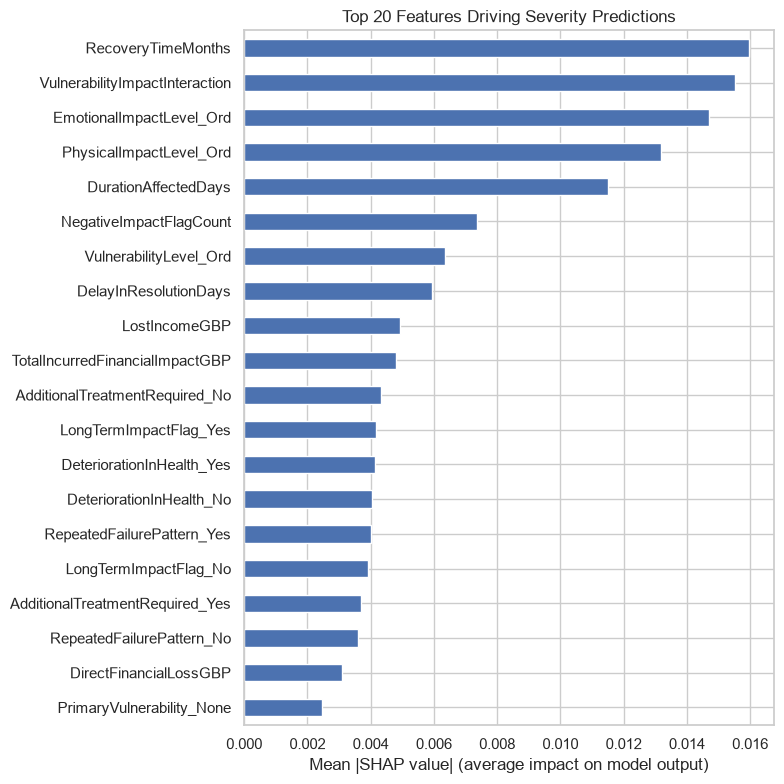

RecoveryTimeMonths                 0.015956
VulnerabilityImpactInteraction     0.015522
EmotionalImpactLevel_Ord           0.014705
PhysicalImpactLevel_Ord            0.013195
DurationAffectedDays               0.011517
NegativeImpactFlagCount            0.007360
VulnerabilityLevel_Ord             0.006356
DelayInResolutionDays              0.005924
LostIncomeGBP                      0.004936
TotalIncurredFinancialImpactGBP    0.004814
AdditionalTreatmentRequired_No     0.004319
LongTermImpactFlag_Yes             0.004156
DeteriorationInHealth_Yes          0.004148
DeteriorationInHealth_No           0.004053
RepeatedFailurePattern_Yes         0.004015
LongTermImpactFlag_No              0.003928
AdditionalTreatmentRequired_Yes    0.003678
RepeatedFailurePattern_No          0.003593
DirectFinancialLossGBP             0.003104
PrimaryVulnerability_None          0.002472
dtype: float64

In [61]:
#overall feature importance (averaged across all classes):

import numpy as np

# Average absolute SHAP value across all samples and all 6 classes = overall importance
mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))
feature_importance = pd.Series(mean_abs_shap, index=X_val_nl.columns).sort_values(ascending=False)

top_20 = feature_importance.head(20)
fig, ax = plt.subplots(figsize=(8, 8))
top_20[::-1].plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('Mean |SHAP value| (average impact on model output)')
ax.set_title('Top 20 Features Driving Severity Predictions')
plt.tight_layout()
plt.show()

top_20

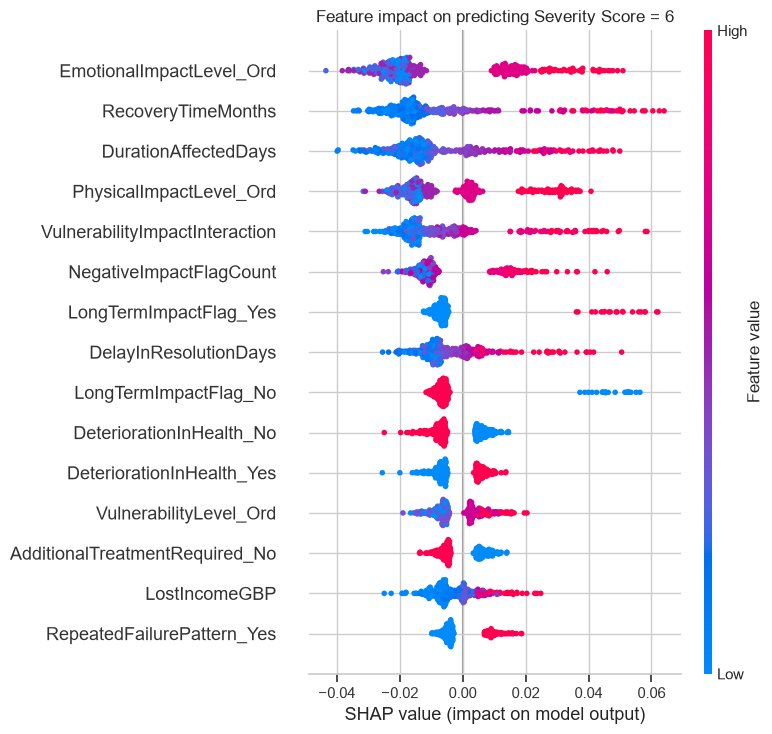

In [62]:
#what drives the highest severity class specifically (class 6):

class_idx = list(best_rf_nl.classes_).index(6)
shap.summary_plot(shap_values[:, :, class_idx], X_val_nl, max_display=15, show=False)
plt.title('Feature impact on predicting Severity Score = 6')
plt.tight_layout()
plt.show()